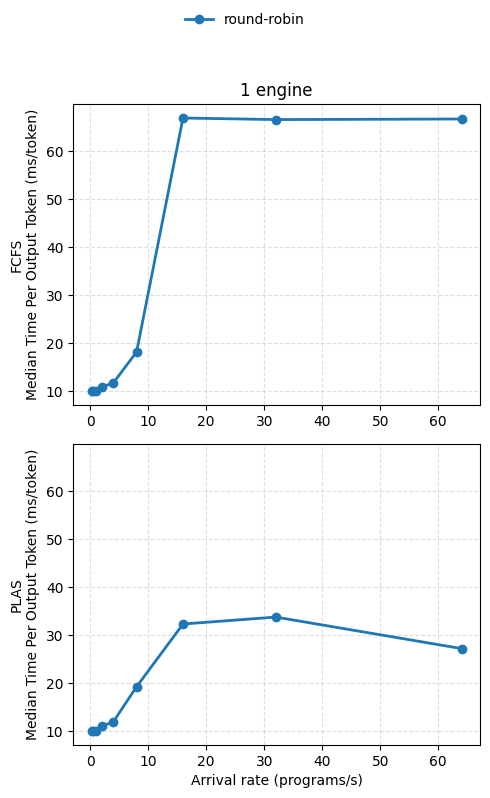

In [11]:
import json
import glob
import re
import matplotlib.pyplot as plt
from collections import defaultdict

# ============================================================
# CONFIG
# ============================================================
OUTPUT_DIRS = {
    "1 engine": "outputs_benchmark_load_balancer_50_1_Qwen4B",
    #"2 engines": "outputs_benchmark_load_balancer_2_engines",
    # "4 engines": "outputs_4_engines",
}

SCHEDULERS = ["fcfs", "plas"]
Y_METRIC = "median_tpot_ms"

# Optional: fixed colors for consistency
COLORS = {
    "round-robin": "#1f77b4",
    "least-waiting": "#ff7f0e",
    "autellix": "#2ca02c",
    "kv-threshold-autellix": "#d62728",
}

# results[engine][scheduler][strategy][rate] = [values]
results = defaultdict(
    lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
)

pattern = re.compile(
    r"output_([^_]+)_([^_]+)_rate([\d.]+)_run\d+\.json"
)


# ============================================================
# LOAD DATA
# ============================================================
for engine_label, folder in OUTPUT_DIRS.items():
    for path in glob.glob(f"{folder}/*.json"):
        filename = path.split("/")[-1]
        match = pattern.match(filename)
        if not match:
            continue

        scheduler = match.group(1)
        strategy = match.group(2)
        rate = float(match.group(3))

        with open(path) as f:
            data = json.load(f)

        value = data["full_metrics"][Y_METRIC]
        results[engine_label][scheduler][strategy][rate].append(value)

# ============================================================
# PLOTTING
# ============================================================
n_rows = len(SCHEDULERS)
n_cols = len(OUTPUT_DIRS)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharey=True
)

# ✅ CORRECT normalization
if n_cols == 1:
    axes = axes.reshape(n_rows, 1)
elif n_rows == 1:
    axes = axes.reshape(1, n_cols)

for col, (engine_label, _) in enumerate(OUTPUT_DIRS.items()):
    for row, scheduler in enumerate(SCHEDULERS):
        ax = axes[row, col]

        for strategy, rate_dict in results[engine_label][scheduler].items():
            rates = sorted(rate_dict.keys())
            values = [
                sum(rate_dict[r]) / len(rate_dict[r]) for r in rates
            ]

            ax.plot(
                rates,
                values,
                marker="o",
                linewidth=2,
                label=strategy
            )

        if row == 0:
            ax.set_title(engine_label)

        if col == 0:
            ax.set_ylabel(f"{scheduler.upper()}\nMedian Time Per Output Token (ms/token)")

        if row == n_rows - 1:
            ax.set_xlabel("Arrival rate (programs/s)")

        ax.grid(True, linestyle="--", alpha=0.4)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(labels),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


In [ ]:
import json
import glob
import re
import matplotlib.pyplot as plt
from collections import defaultdict

# ============================================================
# CONFIG
# ============================================================
MODELS = {
    "Qwen3-4B": "outputs_benchmark_load_balancer_50_1_Qwen4B",
    "Llama3.1-8B": "outputs_benchmark_load_balancer_50_1_Llama31",
}
# MODELS = {
#     "Qwen3-4B": "outputs_benchmark_Qwen3_4B_1000prograns",
#     "Llama3.1-8B": "outputs_benchmark_Llama31_1000prograns",
# }

SCHEDULERS = ["fcfs", "plas"]
# Y_METRIC = "mean_itl_ms"

SCHEDULER_COLORS = {
    "fcfs": "#1f77b4",
    "plas": "#ff7f0e",
}

# ============================================================
# DATA STRUCTURE
# ============================================================
# results[model][scheduler][rate] = [values]
results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

# Filename format:
# output_<scheduler>_round_robin_rate<rate>_runX.json
pattern = re.compile(
    r"output_([^_]+)_round-robin_rate([\d.]+)_run\d+\.json"
)

# ============================================================
# LOAD DATA
# ============================================================
for model_label, folder in MODELS.items():
    for path in glob.glob(f"{folder}/*.json"):
        filename = path.split("/")[-1]
        match = pattern.match(filename)
        if not match:
            continue

        scheduler = match.group(1)
        rate = float(match.group(2))

        if scheduler not in SCHEDULERS:
            continue

        with open(path) as f:
            data = json.load(f)

        value = data["full_metrics"][Y_METRIC]
        results[model_label][scheduler][rate].append(value)

# ============================================================
# PLOTTING
# ============================================================
n_cols = len(MODELS)

fig, axes = plt.subplots(
    1,
    n_cols,
    figsize=(5 * n_cols, 4),
    sharey=True
)

# Normalize axes when only one model
if n_cols == 1:
    axes = [axes]

for col, (model_label, _) in enumerate(MODELS.items()):
    ax = axes[col]

    for scheduler in SCHEDULERS:
        rate_dict = results[model_label][scheduler]
        if not rate_dict:
            continue

        rates = sorted(rate_dict.keys())
        values = [
            sum(rate_dict[r]) / len(rate_dict[r]) for r in rates
        ]

        ax.plot(
            rates,
            values,
            marker="o",
            linewidth=2,
            label=scheduler.upper(),
            color=SCHEDULER_COLORS.get(scheduler),
        )

    ax.set_title(model_label)
    ax.set_xlabel("Arrival rate (programs/s)")
    ax.grid(True, linestyle="--", alpha=0.4)

# Shared Y label
axes[0].set_ylabel(f"{Y_METRIC}")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(labels),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()


# Using Now

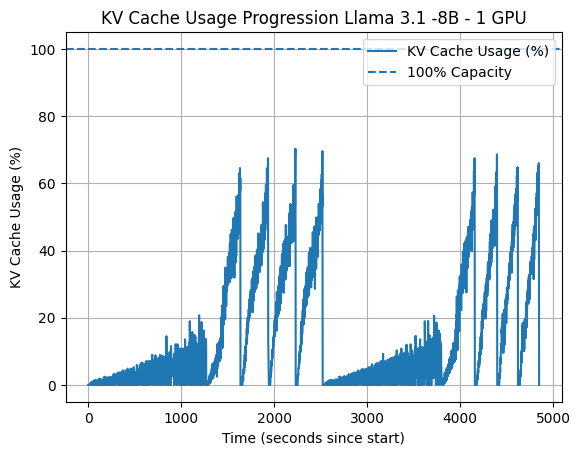

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("outputs_benchmark_50_25_Llama31/kv_cache_usage.csv")

# Normalize time to start at 0
df["time_sec"] = df["timestamp"] - df["timestamp"].iloc[0]

# Convert usage to percentage
df["kv_cache_percent"] = df["kv_cache_usage_perc"]

# Plot
plt.figure()
plt.plot(df["time_sec"], df["kv_cache_percent"], label="KV Cache Usage (%)")

# 100% reference line
plt.axhline(100, linestyle="--", label="100% Capacity")

plt.xlabel("Time (seconds since start)")
plt.ylabel("KV Cache Usage (%)")
plt.title("KV Cache Usage Progression Llama 3.1 -8B - 1 GPU")
plt.legend()
plt.grid(True)

plt.show()


In [36]:
Y_METRIC = "total_e2el_s"

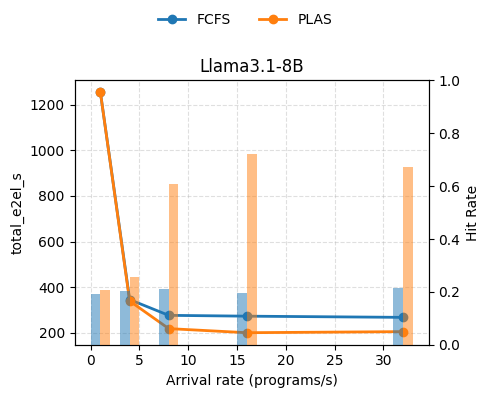

In [37]:
import json
import glob
import re
import matplotlib.pyplot as plt
from collections import defaultdict

# ============================================================
# CONFIG
# ============================================================
MODELS = {
    # "Qwen3-4B": "outputs_benchmark_load_balancer_50_1_Qwen4B",
    "Llama3.1-8B": "outputs_benchmark_50_25_Llama31",
}

SCHEDULERS = ["fcfs", "plas"]


SCHEDULER_COLORS = {
    "fcfs": "#1f77b4",
    "plas": "#ff7f0e",
}

# ============================================================
# DATA STRUCTURE
# ============================================================
results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
hit_rates = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

pattern = re.compile(
    r"output_([^_]+)_round-robin_rate([\d.]+)_run\d+\.json"
)

# ============================================================
# LOAD DATA
# ============================================================
for model_label, folder in MODELS.items():
    for path in glob.glob(f"{folder}/*.json"):
        filename = path.split("/")[-1]
        match = pattern.match(filename)
        if not match:
            continue

        scheduler = match.group(1)
        rate = float(match.group(2))

        if scheduler not in SCHEDULERS:
            continue

        with open(path) as f:
            data = json.load(f)

        # Primary metric
        value = data["full_metrics"][Y_METRIC]
        results[model_label][scheduler][rate].append(value)

        # Hit rate (engine_0 only)
        try:
            hit = data["full_metrics"]["prefix_cache"]["engine_0"]["hit_rate"]
        except KeyError:
            hit = 0

        hit_rates[model_label][scheduler][rate].append(hit)

# ============================================================
# PLOTTING
# ============================================================
n_cols = len(MODELS)

fig, axes = plt.subplots(
    1,
    n_cols,
    figsize=(5 * n_cols, 4),
    sharey=True
)

if n_cols == 1:
    axes = [axes]

for col, (model_label, _) in enumerate(MODELS.items()):
    ax = axes[col]
    ax2 = ax.twinx()  # secondary axis for hit rate

    width = 1
    offset_mult = -0.5

    for i, scheduler in enumerate(SCHEDULERS):
        rate_dict = results[model_label][scheduler]
        hit_dict = hit_rates[model_label][scheduler]

        if not rate_dict:
            continue

        rates = sorted(rate_dict.keys())

        values = [
            sum(rate_dict[r]) / len(rate_dict[r]) for r in rates
        ]

        hits = [
            sum(hit_dict[r]) / len(hit_dict[r]) for r in rates
        ]

        # ---------- BACKGROUND BARS ----------
        offsets = [r + (i + offset_mult) * width for r in rates]

        ax2.bar(
            offsets,
            hits,
            width=width,
            alpha=0.5,
            color=SCHEDULER_COLORS.get(scheduler),
        )

        # ---------- LINE ----------
        ax.plot(
            rates,
            values,
            marker="o",
            linewidth=2,
            label=scheduler.upper(),
            color=SCHEDULER_COLORS.get(scheduler),
        )

    ax.set_title(model_label)
    ax.set_xlabel("Arrival rate (programs/s)")
    ax.grid(True, linestyle="--", alpha=0.4)

    ax2.set_ylim(0, 1)
    ax2.set_ylabel("Hit Rate")

# Shared Y label
axes[0].set_ylabel(f"{Y_METRIC}")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(labels),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()
